In [2]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from hydra import compose, initialize
from models.gru import GRUwithFC
from models.transformer import TransformerModel
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from util.load_dataset import CustomTensorDataset, get_all_file_list
from util.preprocessing import apply_minmax_normalization, generate_batch
from util.tools import seed_everything

sys.path.append("/workspace/apexai")

In [3]:
os.chdir("/workspace")
with initialize(version_base=None, config_path="../conf"):
    config = compose(config_name="config.yaml")

In [4]:
print(f"Model: {config.model.name}")
print(f"Hidden dim: {config.model.architecture.hidden_dim}")
print(f"Batch size: {config.training.batch_size}")

Model: GRU
Hidden dim: 256
Batch size: 256


In [5]:
seed_everything(config.seed)

# Load datasets
x_train_dataset_list = get_all_file_list(config.data_paths.train_dir + "/x_train", "*.csv")  # noqa: F841
y_train_dataset_list = get_all_file_list(config.data_paths.train_dir + "/y_train", "*.csv")  # noqa: F841

x_valid_dataset_list = get_all_file_list(config.data_paths.valid_dir + "/x_valid", "*.csv")  # noqa: F841
y_valid_dataset_list = get_all_file_list(config.data_paths.valid_dir + "/y_valid", "*.csv")  # noqa: F841

x_test_dataset_list = get_all_file_list(config.data_paths.test_dir + "/x_test", "*.csv")  # noqa: F841
y_test_dataset_list = get_all_file_list(config.data_paths.test_dir + "/y_test", "*.csv")  # noqa: F841
print("Datasets loaded successfully.")
print(f"Training samples: {len(x_train_dataset_list)}")
print(f"Validation samples: {len(x_valid_dataset_list)}")
print(f"Test samples: {len(x_test_dataset_list)}")

Datasets loaded successfully.
Training samples: 572
Validation samples: 114
Test samples: 150


In [6]:
# Generate batches
x_train_batch, y_train_batch = generate_batch(x_train_dataset_list, y_train_dataset_list, config)
x_val_batch, y_val_batch = generate_batch(x_valid_dataset_list, y_valid_dataset_list, config)

# Create datasets
train_dataset = CustomTensorDataset(x_train_batch, y_train_batch)
val_dataset = CustomTensorDataset(x_val_batch, y_val_batch)

In [7]:
train_dataset.features.shape, train_dataset.labels.shape

(torch.Size([15329, 100, 9]), torch.Size([15329]))

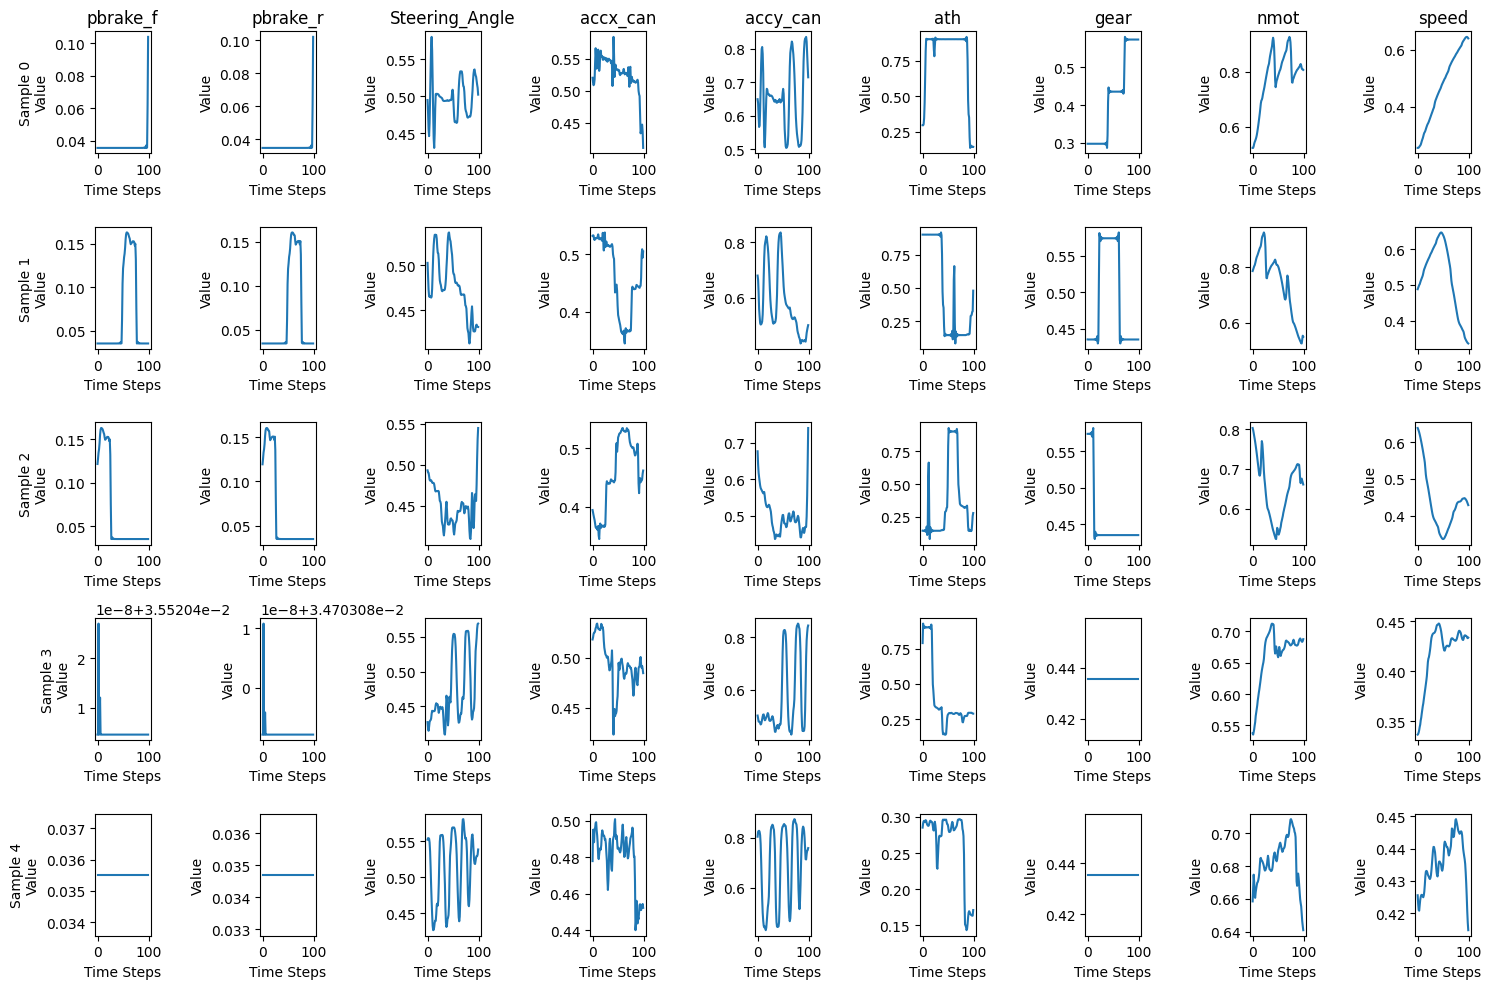

In [8]:
timestep = np.arange(0, train_dataset.features[0].shape[0])
N = 5
n_features = train_dataset.features[0].shape[1]

fig, ax = plt.subplots(N, n_features, figsize=(15, 10))
feature_names = config.data.preprocessing.features

for i in range(N):
    features = train_dataset.features[i]
    for j in range(n_features):
        ax[i, j].plot(timestep, features[:, j].numpy())
        ax[i, j].set_xlabel("Time Steps")
        ax[i, j].set_ylabel("Value")

        if i == 0:
            ax[i, j].set_title(feature_names[j])

        if j == 0:
            ax[i, j].set_ylabel(f"Sample {i}\nValue")

plt.tight_layout()
plt.show()

## Model Inference Test

In [20]:
# Model parameters
model_params = {
    "feature_size": 9,  # pbrake_f, pbrake_r, Steering_Angle, accx_can, accy_can
    "hidden_dim": 512,
    "num_layers": 3,
    "out_dim": 21,  # 21 drivers
    "dropout_ratio": 0.0,
    "classification": True,
    "batch_first": True,
}


In [21]:
model = GRUwithFC(**model_params)

In [11]:
# model_params = {
#     "feature_size": 9,
#     "hidden_dim": 128,
#     "num_layers": 1,
#     "num_heads": 8,
#     "out_dim": 21,
#     "feedforward_multiplier": 4,
#     "dropout_ratio": 0.1,
#     "classification": True,
# }

In [12]:
# model = TransformerModel(**model_params)

In [13]:
# Check the type of saved model
model_path = "/workspace/apexai/model_resistory/GRU.pth"
# model_path = "/workspace/apexai/simulator/model_repository/model.pth"
checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)

# Check if checkpoint is a model object or state_dict
if isinstance(checkpoint, torch.nn.Module):
    # Model saved as full object
    model = checkpoint
    print("✅ Loaded model object directly")
elif isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    # Model saved as checkpoint with metadata
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"✅ Loaded from checkpoint (epoch: {checkpoint.get('epoch', 'N/A')})")
else:
    # Model saved as state_dict only
    model.load_state_dict(checkpoint)
    print("✅ Loaded state_dict")

model.eval()
print("✅ Model loaded successfully!")

✅ Loaded model object directly
✅ Model loaded successfully!


In [14]:
# Load test datasets
x_test_dataset_list = get_all_file_list(config.data_paths.test_dir + "/x_test", "*.csv")  # noqa: F841
y_test_dataset_list = get_all_file_list(config.data_paths.test_dir + "/y_test", "*.csv")  # noqa: F841
print(f"Test samples: {len(x_test_dataset_list)}")

# Create test batches
x_test_batch, y_test_batch = generate_batch(x_test_dataset_list, y_test_dataset_list, config)
test_dataset = CustomTensorDataset(x_test_batch, y_test_batch)

print(f"Test dataset size: {len(test_dataset)}")
print(f"Input shape: {test_dataset.features.shape}")
print(f"Label shape: {test_dataset.labels.shape}")

Test samples: 150
Test dataset size: 3959
Input shape: torch.Size([3959, 100, 9])
Label shape: torch.Size([3959])


In [15]:
val_loader = torch.utils.data.DataLoader(
    dataset=val_dataset,
    batch_size=256,  # Use a larger batch size for testing. Because no backpropagation is needed.
    shuffle=False,
)

In [16]:
# Create test DataLoader
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=256,  # Use a larger batch size for testing. Because no backpropagation is needed.
    shuffle=False,
)

In [17]:
def inference(model, data_loader):
    # Metrics for Inference
    all_preds = []
    all_labels = []
    all_probs = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    print("Running inference...")
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            # Inference
            outputs = model(batch_x)
            probs = torch.softmax(outputs, dim=-1)
            preds = torch.argmax(outputs, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    print(f"✅ Inference completed: {len(all_preds)} samples")
    return all_preds, all_labels, all_probs

## Validation data performance

In [22]:
val_all_preds, val_all_labels, val_all_probs = inference(model, val_loader)

Running inference...
✅ Inference completed: 4161 samples


In [23]:
def calc_metrics(all_labels, all_preds):
    # Performance Metrics
    accuracy = (all_preds == all_labels).mean()
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")

    print(f"\n{'=' * 50}")
    print("📊 Overall Metrics")
    print(f"{'=' * 50}")
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"F1 (Macro):  {f1_macro:.4f}")
    print(f"F1 (Weighted): {f1_weighted:.4f}")

    # Report for each classes
    print(f"\n{'=' * 50}")
    print("📋 Per-Class Classification Report")
    print(f"{'=' * 50}")
    print(
        classification_report(
            val_all_labels,
            val_all_preds,
            target_names=[f"Vehicle_{i}" for i in range(21)],
            digits=3,
        )
    )

In [24]:
def create_cm(all_labels, all_preds):
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[f"V{i}" for i in range(21)],
        yticklabels=[f"V{i}" for i in range(21)],
        cbar_kws={"label": "Count"},
    )
    plt.title("Confusion Matrix - Vehicle ID Classification", fontsize=16, pad=20)
    plt.xlabel("Predicted Vehicle ID", fontsize=12)
    plt.ylabel("True Vehicle ID", fontsize=12)
    plt.tight_layout()
    plt.show()

    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        xticklabels=[f"V{i}" for i in range(21)],
        yticklabels=[f"V{i}" for i in range(21)],
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Recall (%)"},
    )
    plt.title("Normalized Confusion Matrix", fontsize=16, pad=20)
    plt.xlabel("Predicted Vehicle ID", fontsize=12)
    plt.ylabel("True Vehicle ID", fontsize=12)
    plt.tight_layout()
    plt.show()

In [25]:
calc_metrics(val_all_labels, val_all_preds)


📊 Overall Metrics
Accuracy:    0.0243
F1 (Macro):  0.0117
F1 (Weighted): 0.0093

📋 Per-Class Classification Report
              precision    recall  f1-score   support

   Vehicle_0      0.065     0.095     0.077       275
   Vehicle_1      0.000     0.000     0.000       166
   Vehicle_2      0.000     0.000     0.000       165
   Vehicle_3      0.000     0.000     0.000       101
   Vehicle_4      0.000     0.000     0.000       278
   Vehicle_5      0.000     0.000     0.000       279
   Vehicle_6      0.000     0.000     0.000       169
   Vehicle_7      0.000     0.000     0.000       279
   Vehicle_8      0.029     0.267     0.053        75
   Vehicle_9      0.088     0.089     0.088       124
  Vehicle_10      0.000     0.000     0.000       280
  Vehicle_11      0.015     0.444     0.029        99
  Vehicle_12      0.000     0.000     0.000       162
  Vehicle_13      0.000     0.000     0.000       274
  Vehicle_14      0.000     0.000     0.000       108
  Vehicle_15      0

/opt/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


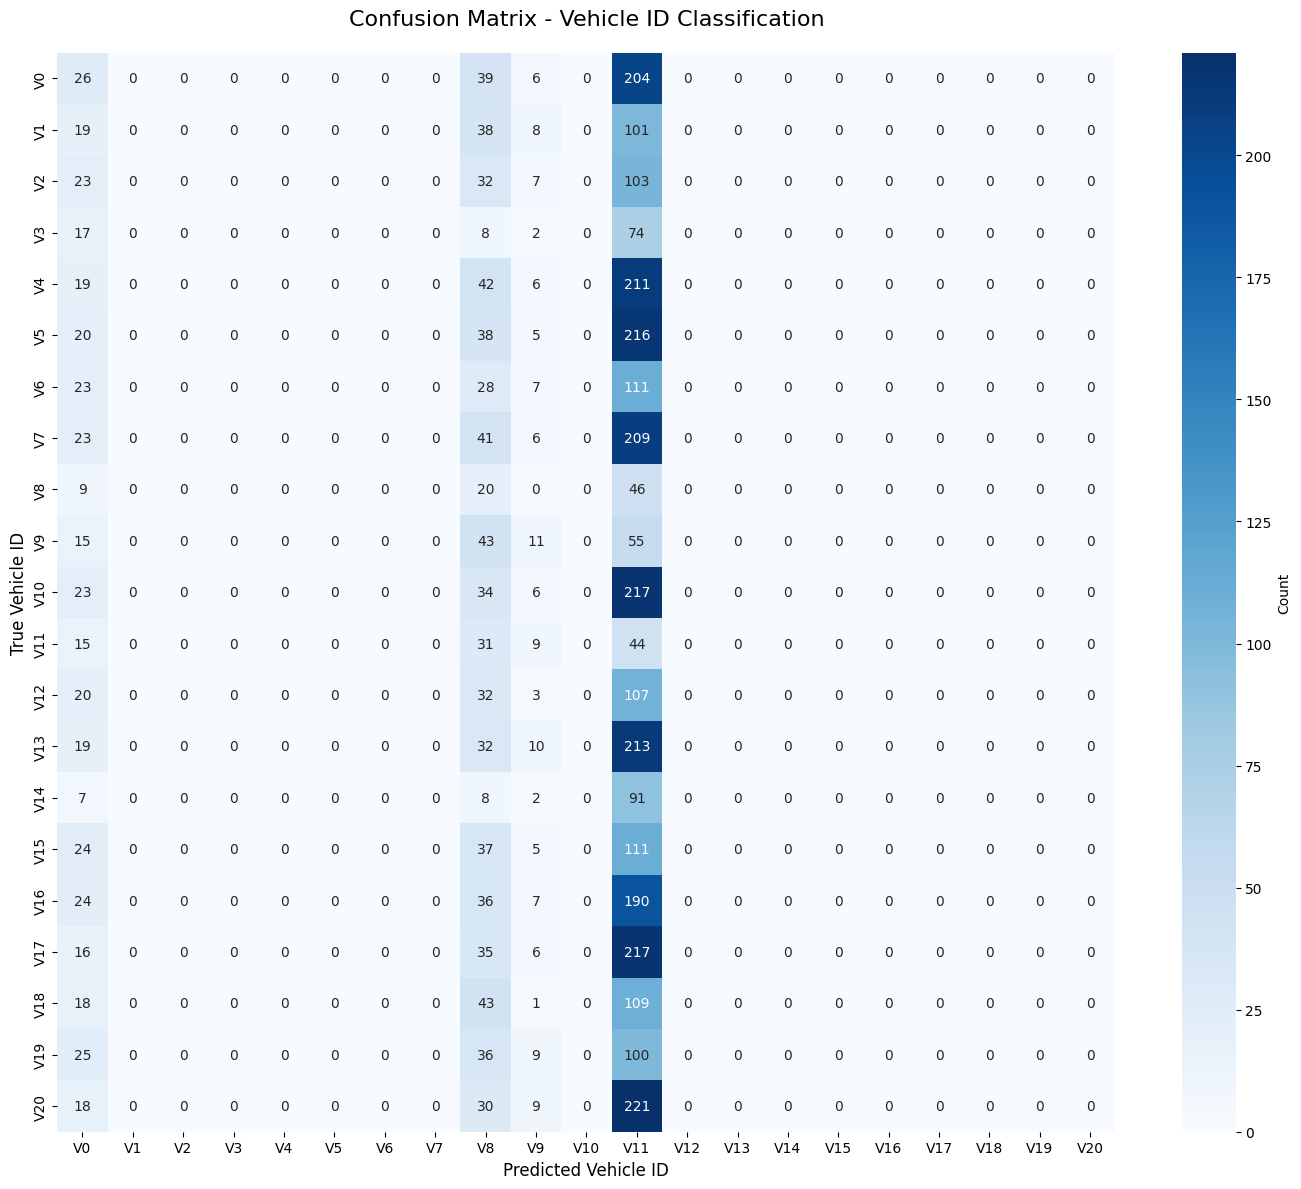

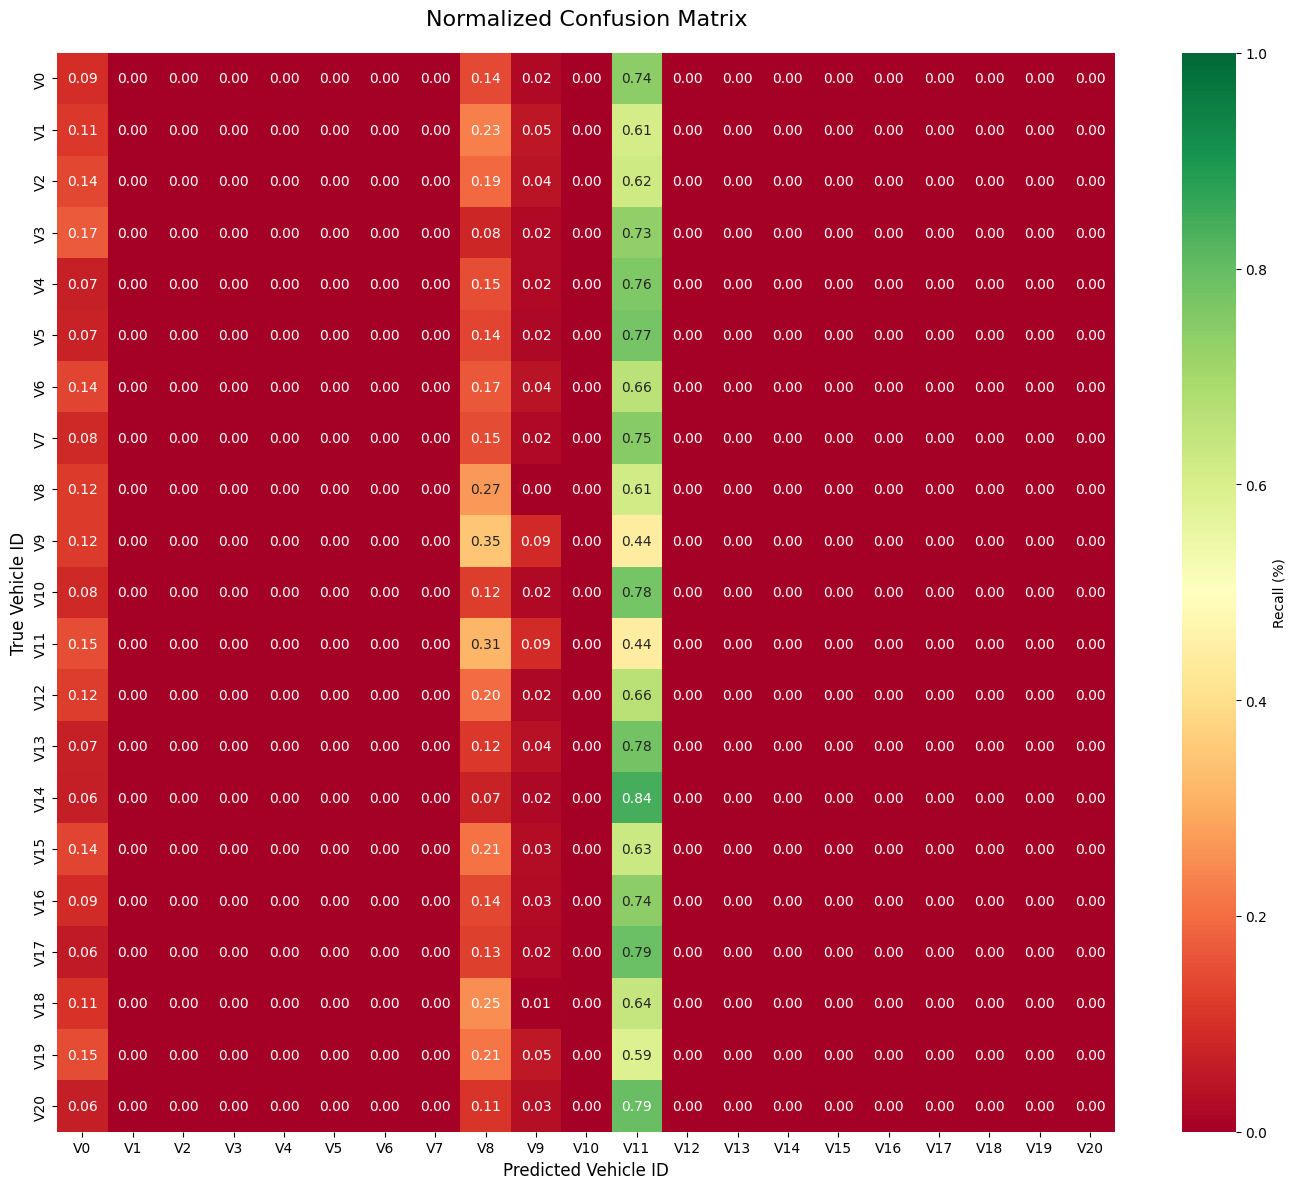

In [26]:
create_cm(val_all_labels, val_all_preds)

## Test data Performance

In [27]:
test_all_preds, test_all_labels, test_all_probs = inference(model, test_loader)

Running inference...
✅ Inference completed: 3959 samples


In [28]:
calc_metrics(test_all_labels, test_all_preds)


📊 Overall Metrics
Accuracy:    0.0399
F1 (Macro):  0.0134
F1 (Weighted): 0.0114

📋 Per-Class Classification Report
              precision    recall  f1-score   support

   Vehicle_0      0.065     0.095     0.077       275
   Vehicle_1      0.000     0.000     0.000       166
   Vehicle_2      0.000     0.000     0.000       165
   Vehicle_3      0.000     0.000     0.000       101
   Vehicle_4      0.000     0.000     0.000       278
   Vehicle_5      0.000     0.000     0.000       279
   Vehicle_6      0.000     0.000     0.000       169
   Vehicle_7      0.000     0.000     0.000       279
   Vehicle_8      0.029     0.267     0.053        75
   Vehicle_9      0.088     0.089     0.088       124
  Vehicle_10      0.000     0.000     0.000       280
  Vehicle_11      0.015     0.444     0.029        99
  Vehicle_12      0.000     0.000     0.000       162
  Vehicle_13      0.000     0.000     0.000       274
  Vehicle_14      0.000     0.000     0.000       108
  Vehicle_15      0

/opt/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


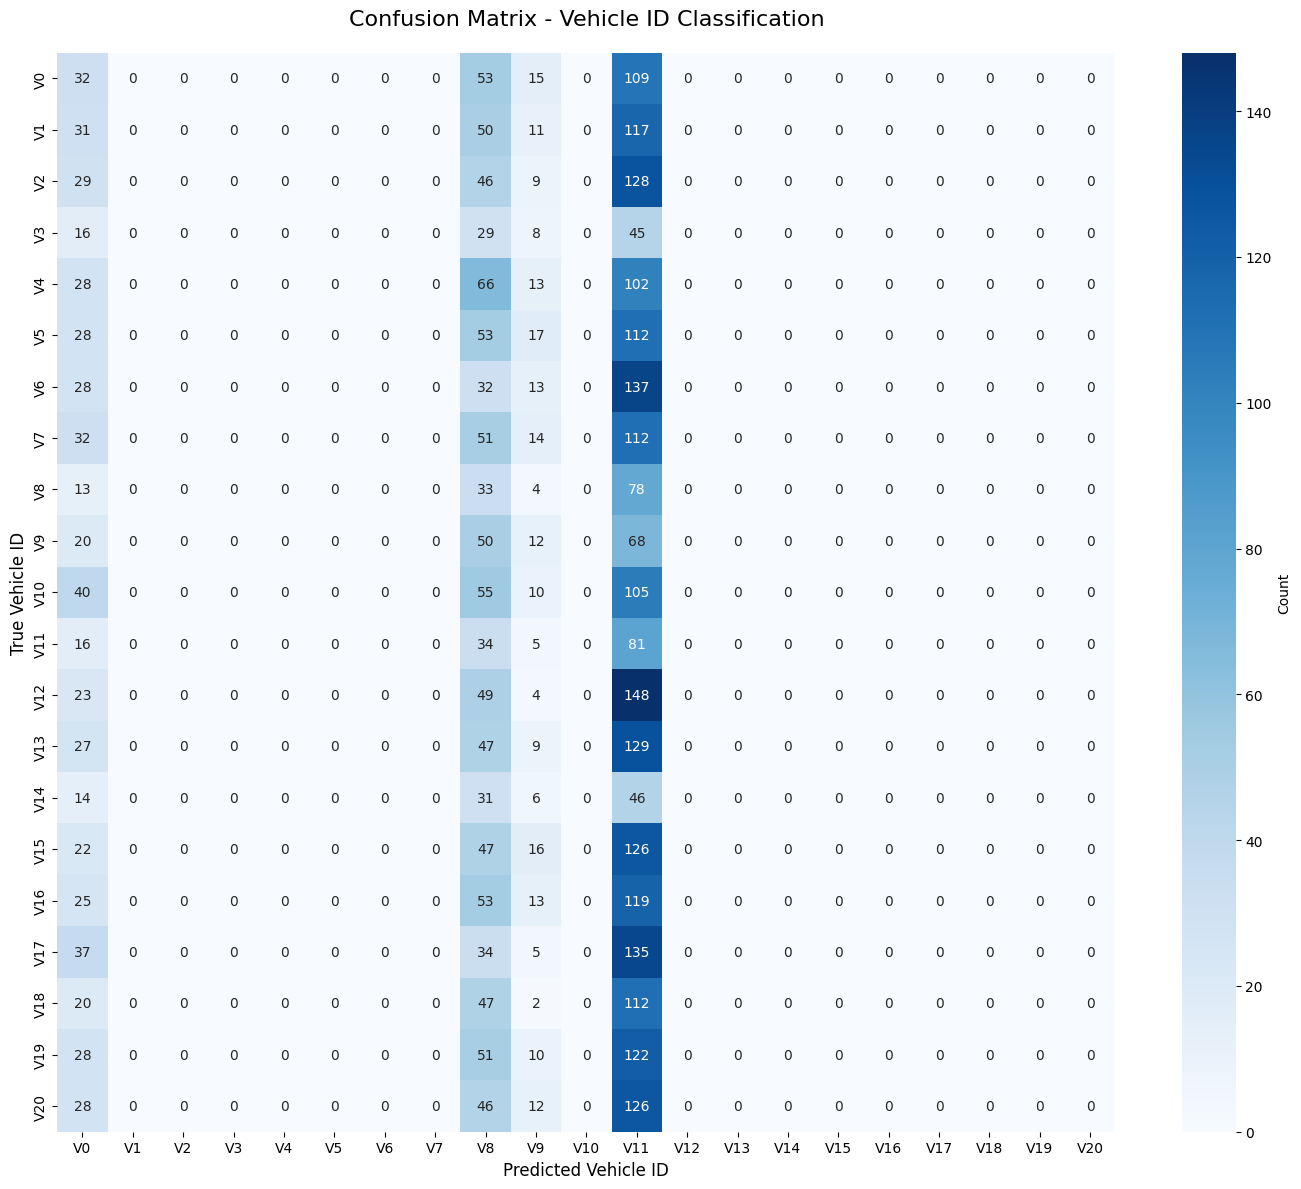

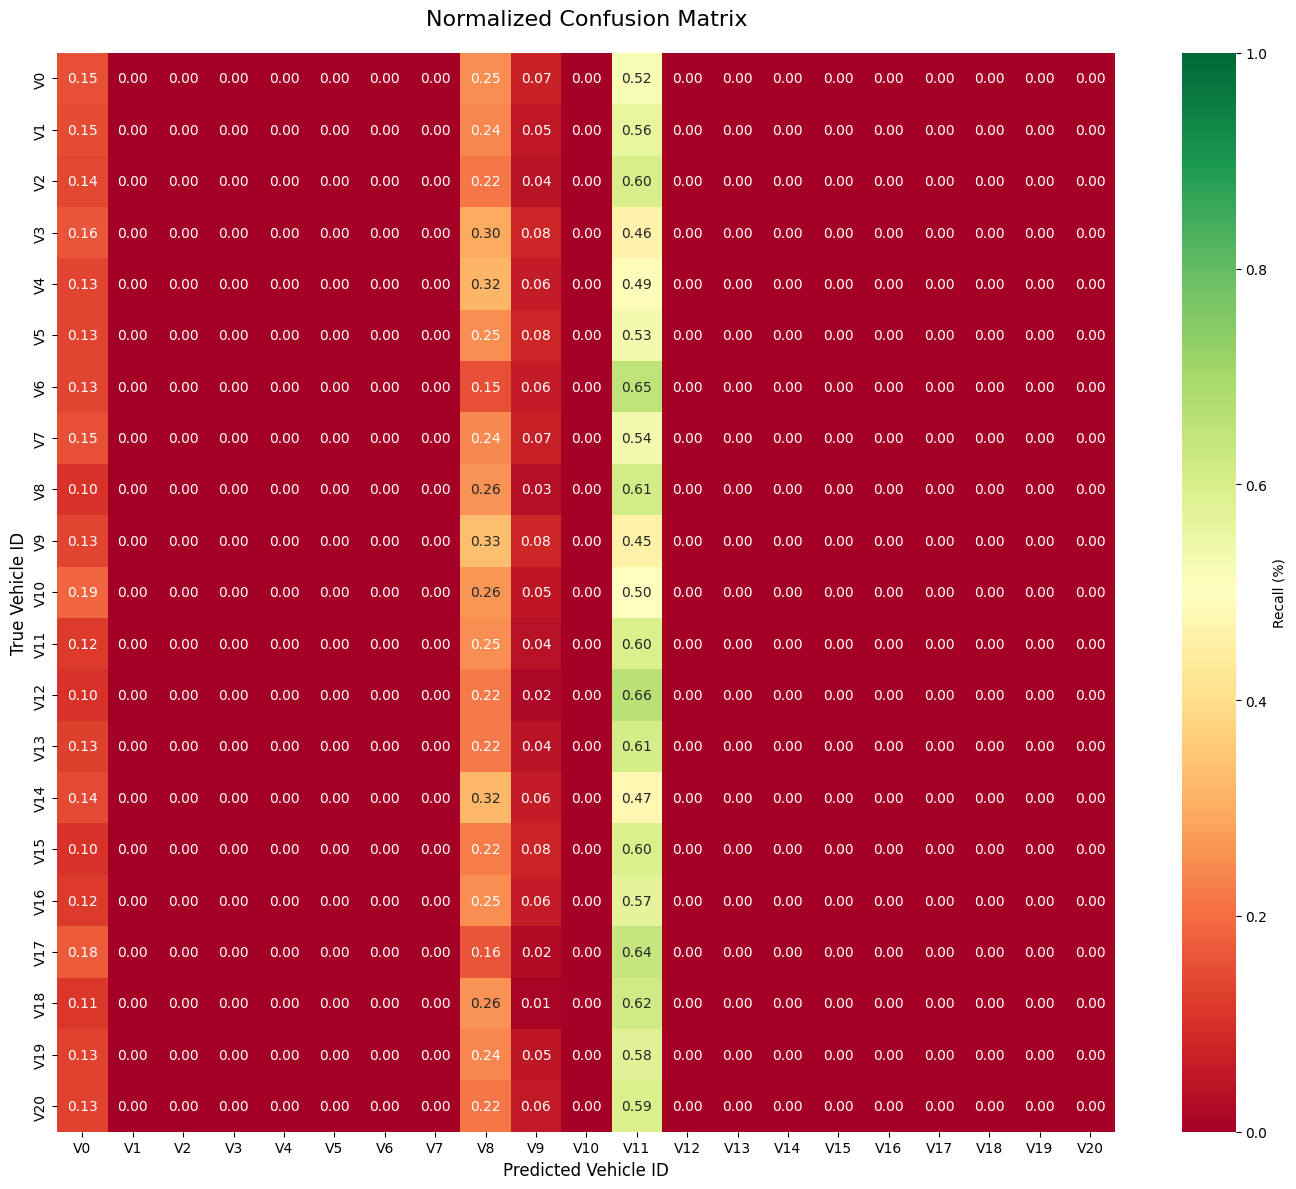

In [29]:
create_cm(test_all_labels, test_all_preds)

## Data Distribution Analysis for Normalization


In [31]:
import pandas as pd
from tqdm import tqdm

all_x_files = x_train_dataset_list + x_valid_dataset_list + x_test_dataset_list

print(f"Found {len(all_x_files)} CSV files across all splits")
print(f"  Train: {len(x_train_dataset_list)}")
print(f"  Valid: {len(x_valid_dataset_list)}")
print(f"  Test: {len(x_test_dataset_list)}")
print("\nLoading all CSV files...")

# Load all files and concatenate
all_data = []
for csv_file in tqdm(all_x_files):
    df = pd.read_csv(csv_file)
    all_data.append(df)

# Concatenate all data
full_dataset = pd.concat(all_data, ignore_index=True)
print(f"\nTotal samples: {len(full_dataset):,}")
print(f"Columns: {full_dataset.columns.tolist()}")

Found 836 CSV files across all splits
  Train: 572
  Valid: 114
  Test: 150

Loading all CSV files...


100%|██████████| 836/836 [00:05<00:00, 153.27it/s]


Total samples: 1,233,430
Columns: ['elapsed_time', 'speed', 'ath', 'pbrake_f', 'pbrake_r', 'Steering_Angle', 'accx_can', 'accy_can', 'gear', 'nmot', 'timestamp']


In [32]:
features = config.data.preprocessing.features
print(f"Features to analyze: {features}")

stats_dict = {}
for feature in features:
    if feature in full_dataset.columns:
        stats_dict[feature] = {
            "count": len(full_dataset[feature]),
            "mean": full_dataset[feature].mean(),
            "std": full_dataset[feature].std(),
            "min": full_dataset[feature].min(),
            "max": full_dataset[feature].max(),
            "median": full_dataset[feature].median(),
            "q25": full_dataset[feature].quantile(0.25),
            "q75": full_dataset[feature].quantile(0.75),
            "variance": full_dataset[feature].var(),
        }

stats_df = pd.DataFrame(stats_dict).T
print("\n" + "=" * 80)
print("📊 Statistical Summary of All Features")
print("=" * 80)
print(stats_df.to_string())

print("\n" + "=" * 80)
print("🎯 Suggested Min-Max Values for Normalization")
print("=" * 80)
print("\nFor conf/data/toyota_gr86.yaml:")
print("\npreprocessing:")
print("  normalization:")
print("    enabled: true")
print("    min_max:")
min_values = ", ".join([f"{stats_dict[f]['min']:.6f}" for f in features])
max_values = ", ".join([f"{stats_dict[f]['max']:.6f}" for f in features])
print(f"      min: [{min_values}]")
print(f"      max: [{max_values}]")

Features to analyze: ['pbrake_f', 'pbrake_r', 'Steering_Angle', 'accx_can', 'accy_can', 'ath', 'gear', 'nmot', 'speed']

📊 Statistical Summary of All Features
                    count         mean          std           min          max        median          q25          q75      variance
pbrake_f        1233430.0     4.958321    16.239235 -1.009742e-28   180.869085  2.573850e-16     0.000000     0.000599  2.637128e+02
pbrake_r        1233430.0     5.026700    16.407092 -6.681912e-52   182.249066  2.930573e-16     0.000000     0.000636  2.691927e+02
Steering_Angle  1233430.0    -4.236417    39.951133 -4.670572e+02   466.393638 -9.000000e-01   -19.816659    11.302858  1.596093e+03
accx_can        1233430.0     0.020272     0.319039 -2.305603e+00     2.481207  1.072187e-01    -0.005134     0.185582  1.017857e-01
accy_can        1233430.0    -0.094985     0.651480 -3.637093e+00     1.924832 -3.222657e-02    -0.593192     0.241164  4.244261e-01
ath             1233430.0    66.104191    4

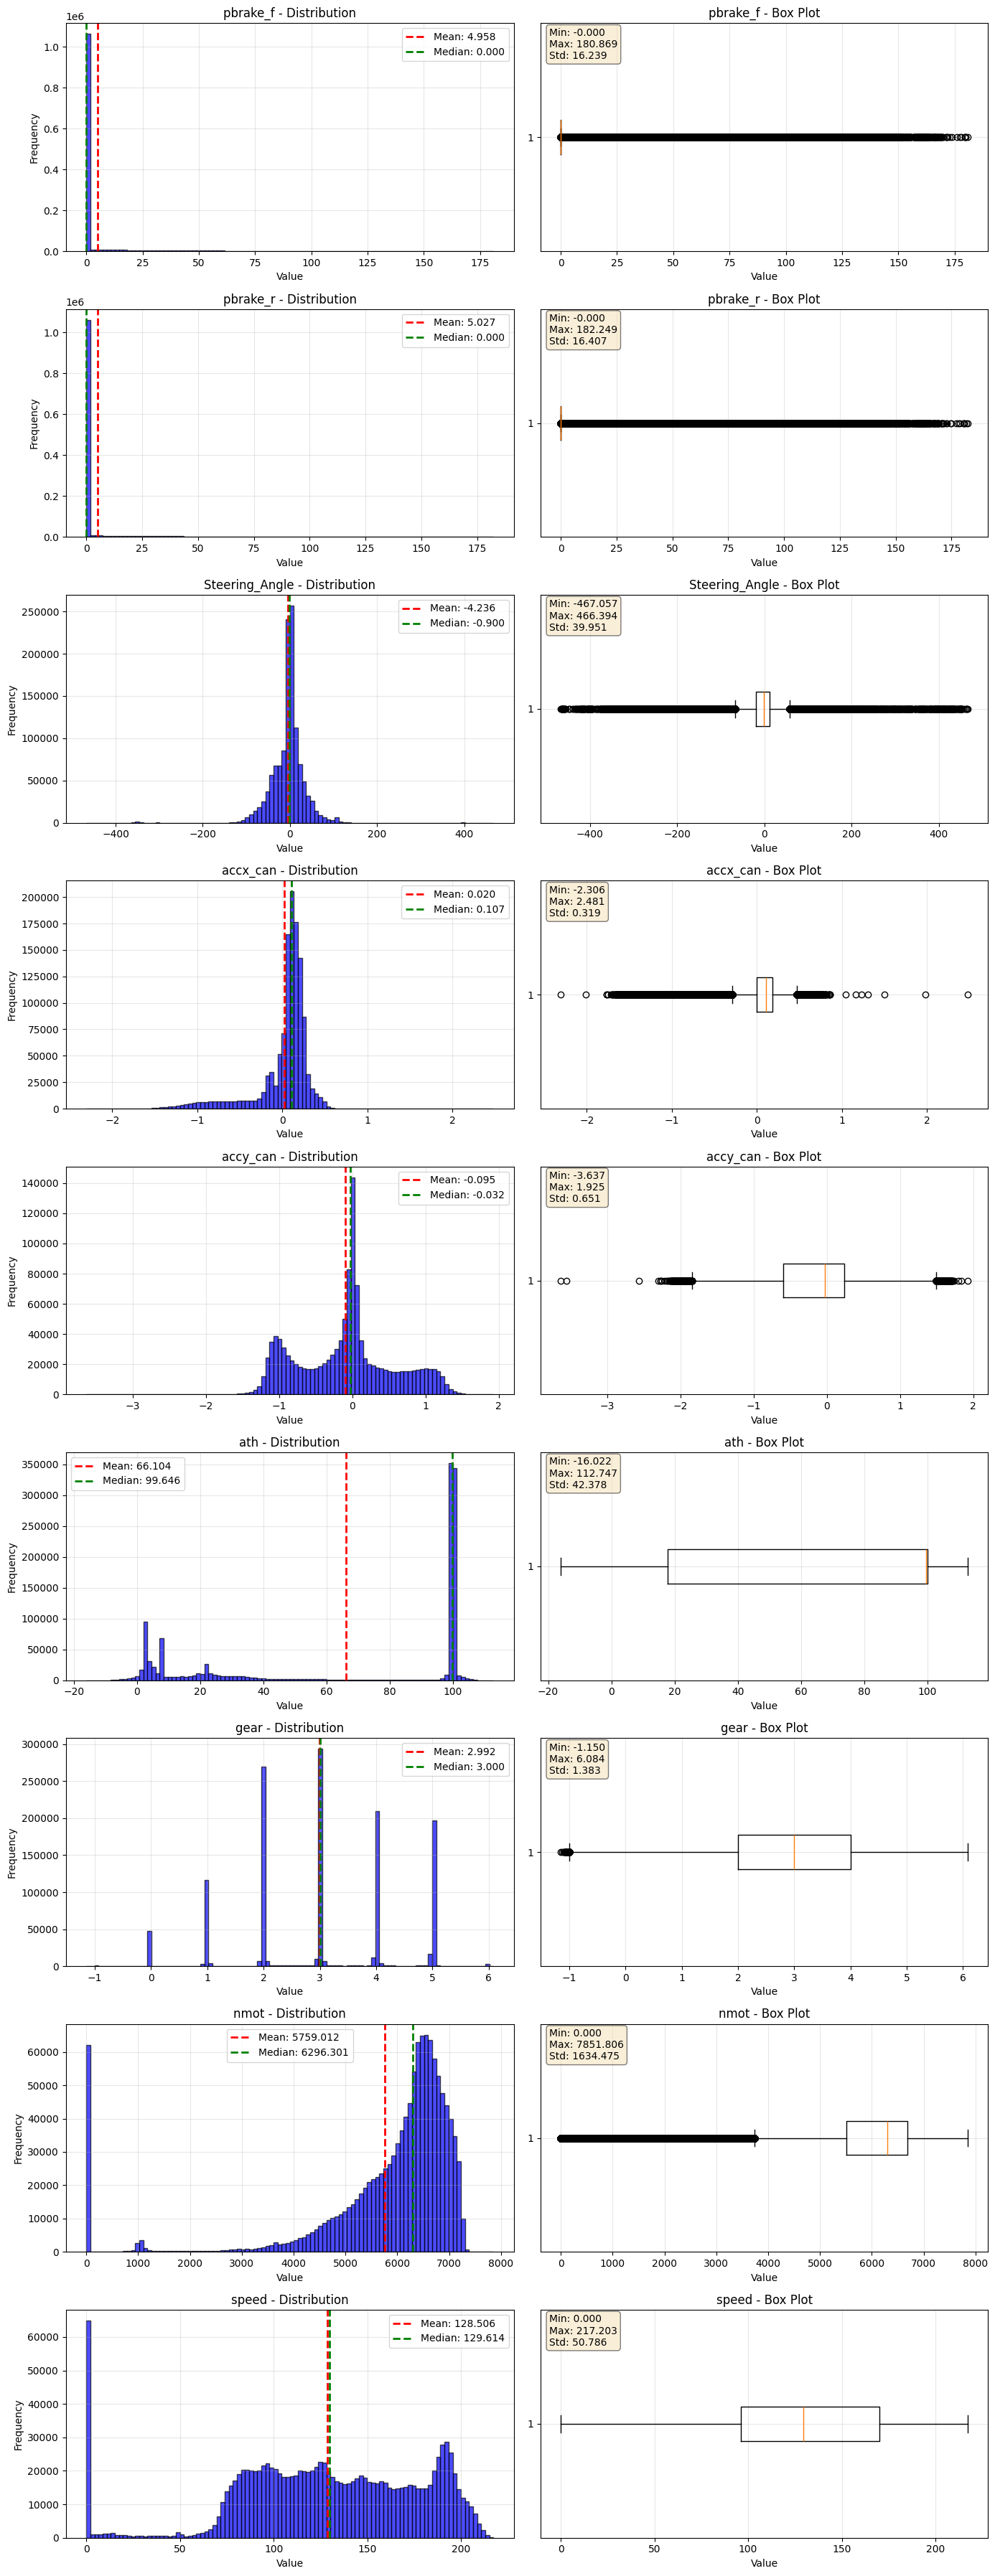

In [33]:
fig, axes = plt.subplots(len(features), 2, figsize=(14, 4 * len(features)))

for idx, feature in enumerate(features):
    if feature in full_dataset.columns:
        data = full_dataset[feature]

        axes[idx, 0].hist(data, bins=100, alpha=0.7, color="blue", edgecolor="black")
        axes[idx, 0].axvline(
            data.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {data.mean():.3f}"
        )
        axes[idx, 0].axvline(
            data.median(),
            color="green",
            linestyle="--",
            linewidth=2,
            label=f"Median: {data.median():.3f}",
        )
        axes[idx, 0].set_xlabel("Value")
        axes[idx, 0].set_ylabel("Frequency")
        axes[idx, 0].set_title(f"{feature} - Distribution")
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)

        axes[idx, 1].boxplot(data, vert=False)
        axes[idx, 1].set_xlabel("Value")
        axes[idx, 1].set_title(f"{feature} - Box Plot")
        axes[idx, 1].grid(True, alpha=0.3)

        stats_text = f"Min: {data.min():.3f}\nMax: {data.max():.3f}\nStd: {data.std():.3f}"
        axes[idx, 1].text(
            0.02,
            0.98,
            stats_text,
            transform=axes[idx, 1].transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        )

plt.tight_layout()
plt.show()